# llama3.1:8b — how well does it label DMPs?

The pipeline reads a Data Management Plan and labels every piece of text as one of
five things: a **title**, a **section heading**, a **description**, a **question**, or
an **answer**.

This notebook shows how close it gets to a human annotation of the same 10 documents,
and then looks at three concrete cases where it goes wrong.


In [1]:
import os
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from dmpbridge.core import paths
from dmpbridge.evaluation.evaluate import (
    load_method as load_method_old, extract_gold, _match_structured,
    _confusion_from_match, micro_prf1, compute_f1_rows, resolve_old_gt_path,
)
from dmpbridge.evaluation.annotation_rules import (
    convert_tag_to_final, load_method_new, resolve_new_gt_path, FINAL_DIR,
)

MODEL, TAG = 'llama3.1:8b', 'llama3.1-8b_pdfplumber_whole_doc'
# Colours are the reference data-viz palette, used unchanged: a single blue hue
# for magnitude, and its sequential ramp for the heatmap. One measure, one hue —
# no categorical colouring, so nothing here encodes identity by colour alone.
BLUE      = '#2a78d6'   # slot 1
BLUE_DARK = '#1c5cab'   # same hue, darker step — used to emphasise, not recolour
INK       = '#0b0b0b'
MUTED     = '#52514e'
SURFACE   = '#fcfcfb'
RAMP      = ['#cde2fb', '#b7d3f6', '#9ec5f4', '#86b6ef', '#6da7ec',
             '#5598e7', '#3987e5', '#2a78d6', '#256abf', '#1c5cab', '#184f95']

from matplotlib.colors import LinearSegmentedColormap
BLUES = LinearSegmentedColormap.from_list('dmp_blue', ['#ffffff'] + RAMP)

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'text.color': INK, 'axes.labelcolor': MUTED,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.edgecolor': '#d8d8d4', 'axes.titlecolor': INK,
    'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
})

df_a, conf_a, err_a = load_method_old(TAG, exclude=[])
convert_tag_to_final(TAG)
df_b, conf_b, err_b = load_method_new(TAG, exclude=[])
print(f'{MODEL} — {len(df_a)} documents')


llama3.1:8b — 10 documents


## 1 — The score

Three numbers, all out of 100:

| | |
|---|---|
| **Found** | of everything in the human annotation, how much did it locate? |
| **Correct** | of everything it produced, how much was right? |
| **F1** | the two combined — the single number to judge it on |

A model cannot score well on F1 by playing safe and producing very little, or by
producing everything it can think of. It has to do both well.


  Found      72.7%
  Correct    53.9%
  F1         61.9%


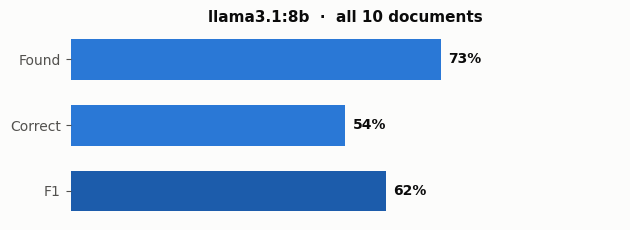

In [2]:
m = micro_prf1(conf_a)
print(f'  Found     {m["recall"] * 100:5.1f}%')
print(f'  Correct   {m["precision"] * 100:5.1f}%')
print(f'  F1        {m["f1"] * 100:5.1f}%')

fig, ax = plt.subplots(figsize=(6.4, 2.4))
vals = [m['recall'] * 100, m['precision'] * 100, m['f1'] * 100]
bars = ax.barh(['Found', 'Correct', 'F1'], vals,
               color=[BLUE, BLUE, BLUE_DARK], height=0.62)
for b, v in zip(bars, vals):
    ax.text(v + 1.5, b.get_y() + b.get_height() / 2, f'{v:.0f}%',
            va='center', fontweight='bold', color=INK, fontsize=10)
ax.set_xlim(0, 108)
ax.set_xticks([])
ax.invert_yaxis()
ax.set_title(f'{MODEL}  ·  all 10 documents')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


## 2 — Which of the five labels are hard

`in annotation` is how many examples of that label a human marked. Where that number
is small, the score moves a lot on very little evidence.


label                         F1   in annotation
------------------------------------------------
title                      90.0%              10
section.title              68.6%              43
section.description        75.0%               8
question.text               4.2%              16
answer.text                72.6%              55


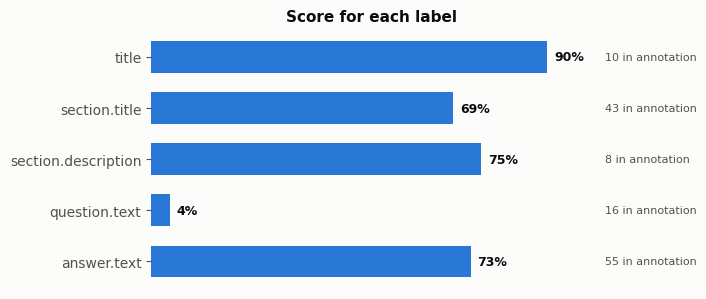

In [3]:
fa = compute_f1_rows(conf_a).set_index('label')

print(f"{'label':<24}{'F1':>8}{'in annotation':>16}")
print('-' * 48)
for lab, r in fa.iterrows():
    print(f"{lab:<24}{r['f1'] * 100:>7.1f}%{int(r['support']):>16}")

fig, ax = plt.subplots(figsize=(7.2, 3.1))
vals = (fa['f1'] * 100).values
ax.barh(range(len(fa)), vals, color=BLUE, height=0.62)
for i, (v, n) in enumerate(zip(vals, fa['support'])):
    ax.text(v + 1.5, i, f'{v:.0f}%', va='center', fontweight='bold',
            color=INK, fontsize=9)
    ax.text(103, i, f'{int(n)} in annotation', va='center',
            color=MUTED, fontsize=8)
ax.set_yticks(range(len(fa)))
ax.set_yticklabels(fa.index)
ax.set_xlim(0, 100)
ax.set_xticks([])
ax.invert_yaxis()
ax.set_title('Score for each label')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


## 3 — What gets mistaken for what

The grid below shows every decision the model made.

- **Each row** is what a human said the text was.
- **Each column** is what the model called it.
- **The diagonal** — top-left to bottom-right — is agreement. Darker is better there.
- **Anything off the diagonal** is a mistake, and the position tells you which one.

The last column, *not found*, is text the human marked that the model produced nothing
for. The last row, *invented*, is the reverse: text the model produced that the human
never marked.


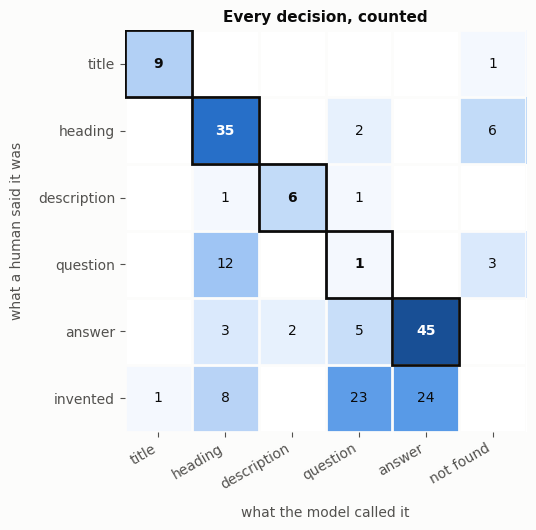

The boxed cells are agreements. Reading the biggest mistakes off the grid:

   24  invented a answer that was not in the annotation
   23  invented a question that was not in the annotation
   12  question called a heading
    8  invented a heading that was not in the annotation
    6  heading that the model did not produce at all


In [4]:
import numpy as np
from dmpbridge.evaluation.evaluate import LABELS

short = [l.replace('section.', 'sec.').replace('question.text', 'question')
          .replace('answer.text', 'answer').replace('sec.title', 'heading')
          .replace('sec.description', 'description') for l in LABELS]

grid = np.zeros((len(LABELS) + 1, len(LABELS) + 1), dtype=int)
for i, true in enumerate(LABELS):
    for j, pred in enumerate(LABELS):
        grid[i, j] = conf_a.get(true, {}).get(pred, 0)
    grid[i, -1] = conf_a.get(true, {}).get('__missed__', 0)
for j, pred in enumerate(LABELS):
    grid[-1, j] = conf_a.get('__no_gold__', {}).get(pred, 0)

fig, ax = plt.subplots(figsize=(7.6, 5.4))
im = ax.imshow(grid, cmap=BLUES, vmin=0, vmax=grid.max())

for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        v = grid[i, j]
        if v == 0:
            continue
        # Label ink follows contrast against the cell, never the series colour.
        ax.text(j, i, str(v), ha='center', va='center', fontsize=10,
                fontweight='bold' if i == j else 'normal',
                color='#ffffff' if v > grid.max() * 0.55 else INK)

ax.set_xticks(range(len(short) + 1))
ax.set_xticklabels(short + ['not found'], rotation=30, ha='right')
ax.set_yticks(range(len(short) + 1))
ax.set_yticklabels(short + ['invented'])
ax.set_xlabel('what the model called it', labelpad=10)
ax.set_ylabel('what a human said it was', labelpad=10)
ax.set_title('Every decision, counted')

ax.set_xticks(np.arange(-.5, grid.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-.5, grid.shape[0], 1), minor=True)
ax.grid(which='minor', color=SURFACE, linewidth=2)
ax.tick_params(which='minor', length=0)

# Outline the diagonal so 'correct' is findable without reading colour.
# Drawn after the grid, or the grid paints over the edges.
for k in range(len(LABELS)):
    ax.add_patch(plt.Rectangle((k - .5, k - .5), 1, 1, fill=False,
                               edgecolor=INK, linewidth=2.0, zorder=5))
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

print('The boxed cells are agreements. Reading the biggest mistakes off the grid:')
print()
names = short + ['not found']
rows  = short + ['invented']
mistakes = sorted(((grid[i, j], rows[i], names[j])
                   for i in range(grid.shape[0]) for j in range(grid.shape[1])
                   if i != j and grid[i, j]), reverse=True)
for count, true, pred in mistakes[:5]:
    if true == 'invented':
        print(f'  {count:>3}  invented a {pred} that was not in the annotation')
    elif pred == 'not found':
        print(f'  {count:>3}  {true} that the model did not produce at all')
    else:
        print(f'  {count:>3}  {true} called a {pred}')


---

## 4 — Three documents, close up

The score says *how much*. These say *what*, using three documents that show three
different things: a common mistake, a bad case, and a good one.


In [5]:
def inspect(n):
    """Score one document and return everything needed to talk about it."""
    gold = extract_gold(resolve_old_gt_path(n))
    recs, extras = _match_structured(paths.structured_path(TAG, n), gold)
    return {
        'gold': gold, 'extras': extras,
        'right':  [r for r in recs if r['pred_label'] == r['gold_label']],
        'wrong':  [r for r in recs if r['pred_label'] and r['pred_label'] != r['gold_label']],
        'missed': [r for r in recs if r['pred_label'] is None],
        'f1': micro_prf1(_confusion_from_match(recs, extras))['f1'] * 100,
    }


def summarise(n, d):
    print(f"sample{n} — {len(d['gold'])} items in the human annotation, F1 {d['f1']:.1f}%")
    print()
    print(f"  labelled correctly   {len(d['right']):>3}")
    print(f"  wrong label          {len(d['wrong']):>3}")
    print(f"  not found            {len(d['missed']):>3}")
    print(f"  invented             {len(d['extras']):>3}")


### Sample 1 — questions mistaken for headings

This document is laid out like most NIH plans: a section heading, then lettered
sub-questions, then the researcher's answer to each.

> **Element 1: Data Type:**  ← section heading
> **A. Types and amount of scientific data expected…**  ← question
> *This project will analyse deidentified data from 48,218 participants…*  ← answer

The model reads the lettered questions as headings instead. That single confusion is
most of what goes wrong here.


In [6]:
d = inspect(1)
summarise(1, d)

print()
print('What it got wrong:')
for r in d['wrong']:
    print(f"  called {r['pred_label']:<20} should be {r['gold_label']}")
    print(f"      {r['gold_text'][:72]}")


sample1 — 28 items in the human annotation, F1 63.3%

  labelled correctly    19
  wrong label            9
  not found              0
  invented               4

What it got wrong:
  called section.title        should be question.text
      B. Scientific data that will be preserved and shared, and the rationale 
  called section.title        should be question.text
      C. Metadata, other relevant data, and associated documentation:
  called question.text        should be answer.text
      The following data will be created as a result of this project: Objectiv
  called section.title        should be question.text
      A. Repository where scientific data and metadata will be archived:
  called section.title        should be question.text
      B. How scientific data will be findable and identifiable:
  called section.title        should be question.text
      C. When and how long the scientific data will be made available:
  called section.title        should be question.text
      

Notice that almost every mistake is the same one, and every one of those items starts
with a letter — `A.`, `B.`, `C.`. The model has a rule in its head that lettered items
are headings. In these documents they are questions.

It costs twice over: the question is not found, **and** a heading is produced that does
not exist in the annotation.


### Sample 5 — text chopped into pieces

A different failure. This document is written with bullet points and long paragraphs,
and the model breaks continuous prose into fragments, then labels the fragments as
questions and answers in their own right.


In [7]:
d = inspect(5)
summarise(5, d)

print()
print('Invented — produced by the model, nowhere in the human annotation:')
for text, label in d['extras'][:8]:
    print(f'  [{label}]')
    print(f'      {text[:72]}')
if len(d['extras']) > 8:
    print(f"  ... and {len(d['extras']) - 8} more")


sample5 — 13 items in the human annotation, F1 41.9%

  labelled correctly     9
  wrong label            4
  not found              0
  invented              17

Invented — produced by the model, nowhere in the human annotation:
  [question.text]
      • Section 2.1 characterizes the aquifer formation that each groundwater 
  [answer.text]
      compares well construction patterns before and after the establishment o
  [question.text]
      • Section 2.2 estimates groundwater components of the water budget (with
  [answer.text]
      yearly (2016-2021) at the field scale.
  [question.text]
      • Section 2.3 integrates research and education through the Scientist Sp
  [section.title]
      Sciences Workshops.
  [answer.text]
      Available data will be systematically reviewed and downloaded. These dat
  [section.title]
      Produced Data:
  ... and 9 more


These are not questions or answers — they are mid-sentence fragments and bullet points
lifted out of a paragraph. The human annotation treats each section as one answer; the
model produces a dozen small pieces instead.

This is why the score can fall even when nothing is *missed*: everything in the
annotation was located, but so much extra was produced alongside it that the result is
no longer usable.


### Sample 10 — what it looks like when it works

Not everything goes badly. This document has a clear structure — plain headings, no
lettered sub-questions, answers in tidy paragraphs — and the model handles it well.


In [8]:
d = inspect(10)
summarise(10, d)

print()
print('Correctly labelled:')
for r in d['right'][:8]:
    print(f"  [{r['gold_label']}]")
    print(f"      {r['gold_text'][:70]}")

if d['wrong']:
    print()
    print('The one thing it got wrong:')
    for r in d['wrong']:
        print(f"  called {r['pred_label']}, should be {r['gold_label']}")
        print(f"      {r['gold_text'][:70]}")


sample10 — 13 items in the human annotation, F1 82.8%

  labelled correctly    12
  wrong label            1
  not found              0
  invented               3

Correctly labelled:
  [title]
      DATA MANAGEMENT
  [section.title]
      1.Policy and Practice
  [answer.text]
      We will ensure that the data obtained and this study will be made avai
  [section.title]
      2. Scope
  [answer.text]
      This Data Management Plan addresses the NSF policy that primary data "
  [section.title]
      3. Data and Metadata Format and Contents
  [answer.text]
      We will make the proposed nano-vesicles (NETs) available to interested
  [section.title]
      4.Accessibility and Data Protection

The one thing it got wrong:
  called question.text, should be answer.text
      All materials will contain acknowledgement of NSF support as per NSF p


The difference is the document, not the model. Sample 10 has no lettered sub-questions
to misread and short, self-contained answers that are hard to fragment.

So the score reflects the shape of a document at least as much as the ability of the
model — worth remembering when comparing an average across only 10 documents.


---

## What this means

**The hard part is telling headings, questions and answers apart** — not reading the
PDF. Titles are almost always right; the confusion is between the three kinds of body
text, which look similar and differ mainly by their role in the document.

**Both kinds of mistake cost the same.** Missing something real and inventing something
that isn't there are penalised equally, which is why a model that over-produces scores
no better than one that under-produces.

**The evidence is thin in places.** Some labels have only a handful of examples across
all 10 documents, so their scores should be read as a rough indication rather than a
measurement. Running the same thing twice already moves the overall score by about
3 points.

For the mechanics of how the score is calculated, and for the annotation rules, see
`annotation_conversion_test.ipynb`.
